# Varible Energy Positron Annihilation Spectroscopy Doppler Broadning Analysis Example
This notebook presents an example for the use of PyPAS to calculate positron profiles.\
This include implantation profile and equilibrium profile after diffusion.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

from scipy.constants import nano, micro, centi, pico

import matplotlib.pyplot as plt
from pyPAS.positron_implantation_profile import ghosh_material_parameters, makhov_material_parameters, ghosh_profile, makhov_profile, multilayer_implantation_profile
from pyPAS.positron_annihilation_profile import scipy_profile_solver, annihilation_fraction_per_layer, profile_solver
from pyPAS.sample import Layer, Material, Sample

# sample description
The implantation is calculated for Si/SiO2 (200 nm) where the positron has 10 keV

In [5]:
D = 2 * (nano/centi)**2/pico

L0 = 40 # nanometers
L1 = 150 # nanometers

absorbtion_length = 10

lambda_b0 = D/L0**2
lambda_b1 = D/L1**2

m0 = Material(name='SiO', diffusion=D, mobility=0, bulk_annihilation_rate=lambda_b0)
m1 = Material(name='SiO2', diffusion=D, mobility=0, bulk_annihilation_rate=lambda_b1)

layer0 = Layer(start=0, width=500, material=m0)
layer1 = Layer(start=50, width=9500, material=m1)

si_sample = Sample([layer0, layer1], absorbtion_length)

# positron implantaton 
here we use ghosh profiles, makhove is also available

In [6]:
data_gos = ghosh_material_parameters()
#data_mak = makhov_material_parameters()

In [7]:
Sio2_parameters = data_gos.iloc[19]
Si_parameters = data_gos.iloc[5]

In [8]:
implantation_depth = np.linspace(0, si_sample.sample_length(), 10000)
positron_implantation_profile = multilayer_implantation_profile(positron_energy=10,
                                                                  depth_vector=implantation_depth,
                                                                  widths=[si_sample.layers[0].width,si_sample.layers[1].width],
                                                                  materials_parameters=[Sio2_parameters, Si_parameters],
                                                                  densities=[Sio2_parameters.density, Si_parameters.density],
                                                                  implantation_profile_function=ghosh_profile)

(0.0, 0.0015717744424926354)

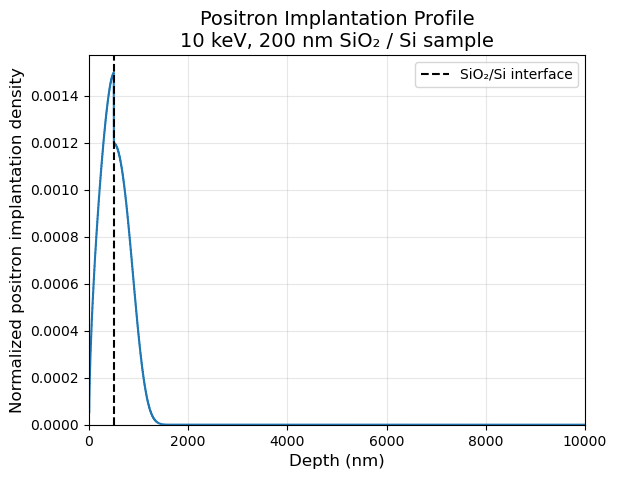

In [17]:
positron_implantation_profile.plot()
                                   # Labels & title
plt.xlabel("Depth (nm)", fontsize=12)
plt.ylabel("Normalized positron implantation density", fontsize=12)
plt.title("Positron Implantation Profile\n10 keV, 200 nm SiO₂ / Si sample", fontsize=14)

# Layer boundary line (200 nm oxide)
oxide_thickness = si_sample.layers[0].width
plt.axvline(oxide_thickness, color="k", linestyle="--", label="SiO₂/Si interface")

# Cosmetics
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, si_sample.sample_length())
plt.ylim(0, 1.05 * positron_implantation_profile.max()) 

# positron equilibrium profile 
In this section we use PyPas fast finite diffrences solver and compare it to the converging scipy solver.\
It is clear that the solutions aligen (Up to some error due to SciPy limeted accuracy)

scipy solve - problems of calculation time

In [19]:
scipy_positron_profile_sol = scipy_profile_solver(positron_implantation_profile, si_sample, num_of_mesh_cells=2000)
scipy_positron_profile_sol_xarray = xr.DataArray(scipy_positron_profile_sol.y[0], coords={'x': scipy_positron_profile_sol.x})

PyPAS solver - very fast and accurate

In [21]:
positron_profile_sol = profile_solver(positron_implantation_profile, si_sample, mesh_size=10000)

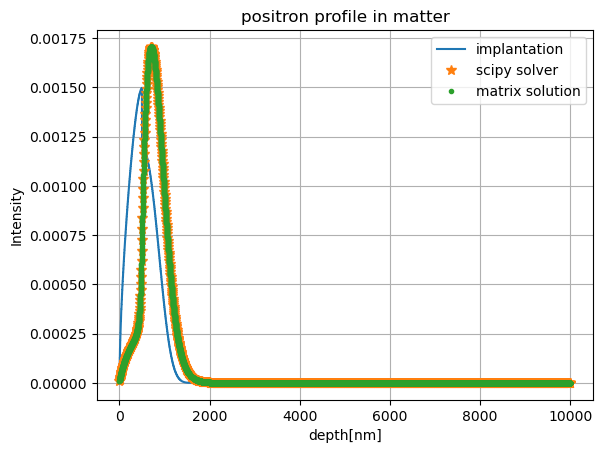

In [27]:
positron_implantation_profile.plot()
(scipy_positron_profile_sol_xarray/scipy_positron_profile_sol_xarray.integrate('x')).plot(marker='*', ls='', markersize=7)
(positron_profile_sol/positron_profile_sol.integrate('x')).plot(marker='.', ls='')

plt.title('positron profile in matter')
plt.grid(True)
plt.xlabel(r'depth[nm]')
plt.ylabel('Intensity')
plt.legend(['implantation', 'scipy solver', 'matrix solution'])